#Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Your Dataset

In [11]:
df = pd.read_csv("ecommerce_project_dataset.csv", encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2023-12-01 08:26,2.55,17850,UK
1,536365,71053,WHITE METAL LANTERN,6,2023-12-01 08:26,3.39,17850,UK
2,536366,84406B,CREAM CUPID HEARTS COAT HANGER,8,2023-12-01 09:00,2.75,13047,UK
3,536367,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2023-12-01 09:30,3.39,12583,France
4,536368,22752,SET 7 BABUSHKA NESTING BOXES,2,2023-12-01 10:00,7.65,13748,Germany


#Check Columns

In [12]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


#Data Cleaning

In [13]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned Shape:", df.shape)

Cleaned Shape: (10, 8)


#Feature Engineering

In [14]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

#KPI Metrics

In [15]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

print("\n📊 KPI METRICS")
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Avg Order Value:", round(avg_order_value, 2))


📊 KPI METRICS
Total Revenue: 205.14
Total Orders: 9
Total Customers: 7
Avg Order Value: 22.79


#Monthly Revenue Trend

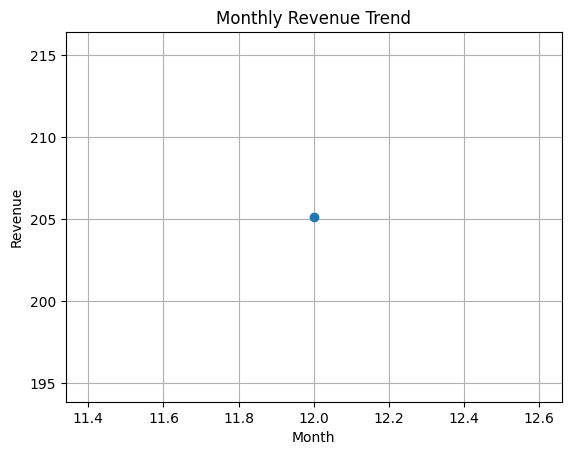

In [16]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

#Top Countries

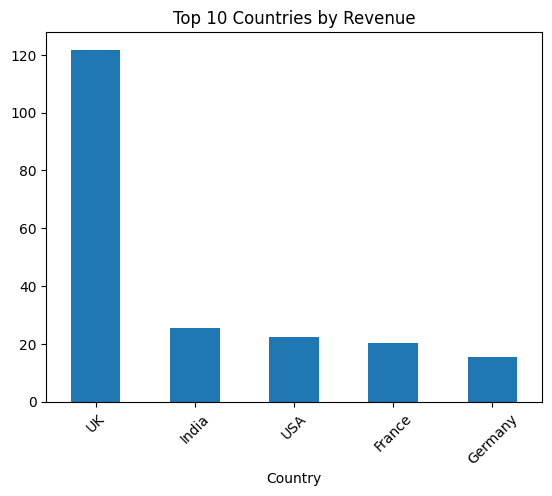

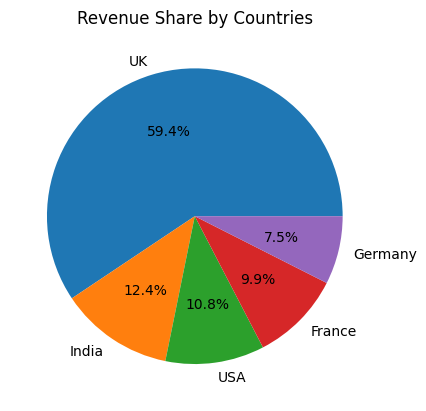

In [17]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Bar chart
plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)
plt.show()

# Pie chart
plt.figure()
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Share by Countries")
plt.ylabel('')
plt.show()

#Sales by Hour

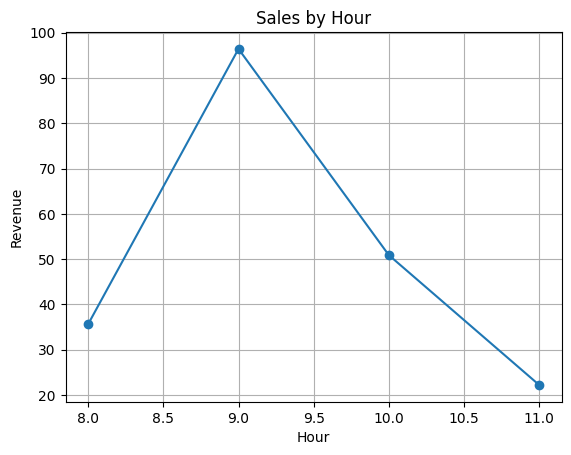

In [18]:
hourly_sales = df.groupby('Hour')['TotalPrice'].sum()

plt.figure()
hourly_sales.plot(marker='o')
plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid()
plt.show()

#RFM Segmentation

#Create RFM

In [19]:
import datetime as dt

latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

#Scoring

In [23]:
rfm['R_score'] = rfm['Recency'].map({0: 2, 1: 1})
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

#Segment Customers

In [24]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'VIP Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Regular Customers    5
Loyal Customers      2
Name: count, dtype: int64


#Segment Visualization

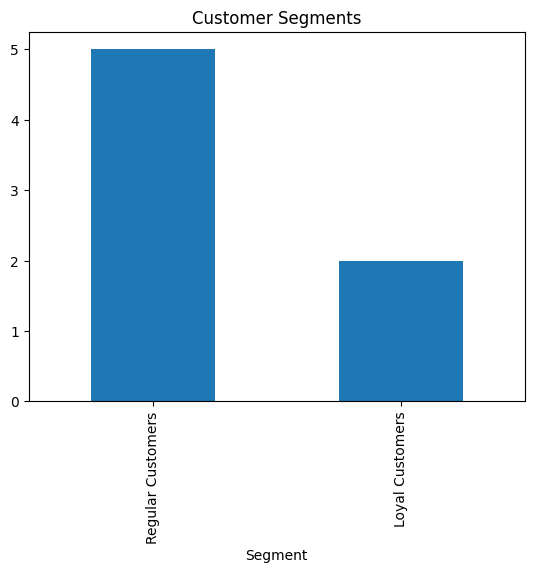

In [25]:
plt.figure()
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

#Final Insights

In [26]:
print("\n✅ Analysis Completed")

print("\nTop Customers:")
print(rfm.sort_values(by='Monetary', ascending=False).head())

print("\nTop Products:")
print(df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head())


✅ Analysis Completed

Top Customers:
            Recency  Frequency  Monetary  R_score F_score M_score RFM_Score  \
CustomerID                                                                    
14096             0          2     64.16        2       4       4       244   
17850             1          1     35.64        1       3       4       134   
15100             0          1     25.50        2       2       3       223   
16029             0          2     22.20        2       4       2       242   
13047             1          1     22.00        1       1       2       112   

                      Segment  
CustomerID                     
14096         Loyal Customers  
17850       Regular Customers  
15100       Regular Customers  
16029         Loyal Customers  
13047       Regular Customers  

Top Products:
Description
ASSORTED COLOUR BIRD ORNAMENT          54.08
GLASS STAR FROSTED T-LIGHT HOLDER      25.50
CREAM CUPID HEARTS COAT HANGER         22.00
KNITTED UNION FLAG HOT